In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage.color as skc
import skimage.io as skio

from itertools import combinations
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm


from utils.utils import (read_config, read_samples_df, 
                         class_to_rgb,
                         class_to_vegetal, class_to_artificial,
                         artificial_to_rgb, vegetal_to_rgb,
                         fast_down_sample, fast_up_sample,
                         read_image_collection
                         )
 

In [2]:
# massage this to get the correct project root path (e.g. /../xxxx/myProjectName/)
root_dir = Path().resolve().parents[0]
conf = read_config(file_path=root_dir / 'config' /'config.yml', root_dir=root_dir)

Configuration read from /workspaces/flairimages/config/config.yml
file locations are:
{'config': PosixPath('/workspaces/flairimages/config'),
 'dataset': PosixPath('/workspaces/flairimages/data/test'),
 'files_csv': PosixPath('/workspaces/flairimages/data/test/testdataset.csv'),
 'files_df': PosixPath('/workspaces/flairimages/data/test/testdataset.pkl'),
 'image_collection': PosixPath('/workspaces/flairimages/data/test/testimagecollection.npy'),
 'image_collection_index': PosixPath('/workspaces/flairimages/data/test/testimagecollectionindex.npy'),
 'metadata': PosixPath('/workspaces/flairimages/data/flair-1_metadata_aerial.json'),
 'outputs': PosixPath('/workspaces/flairimages/outputs')}


In [3]:
# read the image and masks data in np.array format

# read the sample table in csv format
files_df = read_samples_df(conf=conf)
# set to  indexing by number for simplicity (and memory ?)
files_df.reset_index(drop=False, inplace=True)
files_df.head()


,name,image,mask,domain,zone,patch_centroid_x,patch_centroid_y,patch_centroid_z,date,time,camera
0,IMG_062613,/workspaces/flairimages/data/test/flair_1_aeri...,/workspaces/flairimages/data/test/flair_1_labe...,D012_2019,Z10_UU,705075.2,6358476.8,701.719971,2019-08-14,10h56,UCE-M3-f100
1,IMG_062614,/workspaces/flairimages/data/test/flair_1_aeri...,/workspaces/flairimages/data/test/flair_1_labe...,D012_2019,Z10_UU,705177.6,6358476.8,711.409973,2019-08-14,10h56,UCE-M3-f100
2,IMG_062615,/workspaces/flairimages/data/test/flair_1_aeri...,/workspaces/flairimages/data/test/flair_1_labe...,D012_2019,Z10_UU,705280.0,6358476.8,723.130005,2019-08-14,10h56,UCE-M3-f100
3,IMG_062616,/workspaces/flairimages/data/test/flair_1_aeri...,/workspaces/flairimages/data/test/flair_1_labe...,D012_2019,Z10_UU,705382.4,6358476.8,735.22998,2019-08-14,10h56,UCE-M3-f100
4,IMG_062617,/workspaces/flairimages/data/test/flair_1_aeri...,/workspaces/flairimages/data/test/flair_1_labe...,D012_2019,Z10_UU,705495.15,6358481.22,737.109985,2019-08-14,10h30,UCE-M3-f100


In [4]:
image_data, image_indices = read_image_collection(conf=conf)


In [5]:

def show_image_and_masks(img:np.array,mask:np.array): 
    """
    Display the image and the masks in a 2x3 grid
    """   #
    plt.subplot(2,3,1)
    plt.imshow(img[:,:,:3])
    plt.title("R-G-B")
    plt.axis("off")
    #
    plt.subplot(2,3,2)
    plt.imshow(img[:,:,3:4])
    plt.title("NIR")
    plt.axis("off")
    #
    plt.subplot(2,3,3)
    plt.imshow(img[:,:,4])
    plt.title("Elévation")
    plt.axis("off")
    #
    msk_rgb = class_to_rgb(arr=mask, conf=conf)
    plt.subplot(2,3,4)
    plt.imshow(msk_rgb)
    plt.title("Mask")
    plt.axis("off")
    #
    msk_artificial = class_to_artificial(arr=mask, conf=conf)
    msk_rgb = artificial_to_rgb(arr=msk_artificial, conf=conf)
    plt.subplot(2,3,5)
    plt.imshow(msk_rgb)
    plt.title("Artificiel")
    plt.axis("off")
    #
    msk_vegetal = class_to_vegetal(arr=mask, conf=conf)
    msk_rgb = vegetal_to_rgb(arr=msk_vegetal, conf=conf)
    plt.subplot(2,3,6)
    plt.imshow(msk_rgb)
    plt.title("Végétal")
    plt.axis("off")
    #
    plt.tight_layout()


Full resolution original image


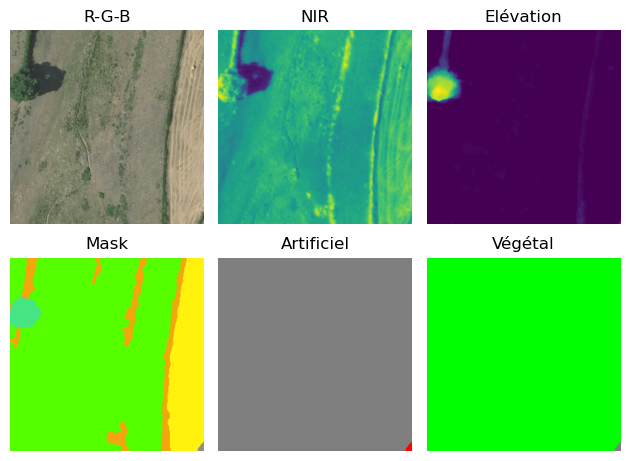

Downsampled image


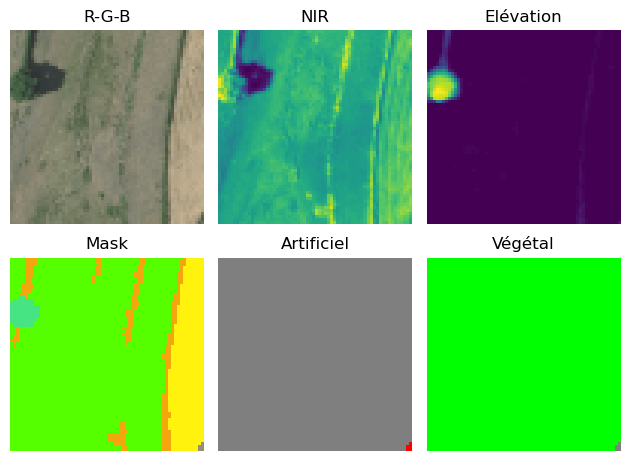

conf['image_shape'] is [512, 512, 5],
found (512, 512, 5) in actual image, dtype:uint8
Actual mask of shape (512, 512) , dtype:uint8
found (64, 64, 5) in downsampled image, dtype:uint8
downsampled mask of shape (64, 64) , dtype:uint8
min=(46, 52, 44, 49, 0),
max=(198, 180, 151, 160, 76)


In [6]:
# see some images in original resolution and 
# set seed for df.sample() to get reproducible results
if False:
    seed = 10041958
    np.random.seed(seed)

#TODO: select a random index in image_indices, not directly from df
# select a random record from df
# and extract the name, image and mask file paths.
some_i = np.random.choice(image_indices.shape[0])
im_index = image_indices[some_i]

# down_sampled image and mask
img = image_data[some_i,:,:,:-3]
mask = image_data[some_i,:,:,-3]

# full resolution image and mask
name, image_file, mask_file = files_df.iloc[im_index][['name','image', 'mask']].values
img_full_resolution = skio.imread(image_file, plugin='tifffile')
mask_full_resolution = skio.imread(mask_file)
#
print(f"Full resolution original image")
show_image_and_masks(img=img_full_resolution, mask=mask_full_resolution)
plt.show()
print(f"Downsampled image")
show_image_and_masks(img=img, mask=mask)
plt.show()


#TODO: do the same for the downsampled image and mask
#    
print(f"conf['image_shape'] is {conf['image_shape']},")
print(f"found {img_full_resolution.shape} in actual image, dtype:{img_full_resolution.dtype}")
print(f"Actual mask of shape {mask_full_resolution.shape} , dtype:{mask_full_resolution.dtype}")
print(f"found {img.shape} in downsampled image, dtype:{img_full_resolution.dtype}")
print(f"downsampled mask of shape {mask.shape} , dtype:{mask.dtype}")

print(f"min={tuple(img.min(axis=(0,1)))},\nmax={tuple(img.max(axis=(0,1)))}")


In [7]:
# Here we prepare dataframes of images and pixel for training and testing
# we will train the model pixel by pixel by subsampling the train images
n_pixel_train = 10000
n_pixels_test = 10000
# split the images in train and test
train_image_data, test_image_data,train_indices, test_indices = train_test_split(image_data,
                                                                             image_indices,
                                                                             test_size=0.2,
                                                                             train_size=None,
                                                                             random_state=42)

# Here we make a dataframe of pixels in the train images
# that we will subsample to train the model pixel by pixel

# we don't need the image location in the dataframe to train the model pixel by pixel
pixel_df_columns = {#'index':files_df.index.dtype,
                    'R':np.uint8, 
                    'G':np.uint8, 
                    'B':np.uint8, 
                    'NIR':np.uint8, 
                    'Elevation':np.uint8,
                    'Class':np.uint8,
                    'Artificial':np.uint8,
                    'Vegetal':np.uint8}

# put all the pixels channels in columns
print(train_image_data.shape)
train_pixel_df = pd.DataFrame(data=train_image_data.reshape(-1, train_image_data.shape[-1]),
                              columns=pixel_df_columns.keys(), 
                              dtype=np.uint8).sample(n=n_pixel_train, random_state=42)
test_pixel_df = pd.DataFrame(data=test_image_data.reshape(-1, train_image_data.shape[-1]),
                              columns=pixel_df_columns.keys(), 
                              dtype=np.uint8).sample(n=n_pixels_test, random_state=43)
print(train_pixel_df.info())
print(test_pixel_df.info())


(8000, 64, 64, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 28246769 to 4876378
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   R           10000 non-null  uint8
 1   G           10000 non-null  uint8
 2   B           10000 non-null  uint8
 3   NIR         10000 non-null  uint8
 4   Elevation   10000 non-null  uint8
 5   Class       10000 non-null  uint8
 6   Artificial  10000 non-null  uint8
 7   Vegetal     10000 non-null  uint8
dtypes: uint8(8)
memory usage: 156.2 KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 5963380 to 5342546
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   R           10000 non-null  uint8
 1   G           10000 non-null  uint8
 2   B           10000 non-null  uint8
 3   NIR         10000 non-null  uint8
 4   Elevation   10000 non-null  uint8
 5   Class       10000 non-null  uint8
 6   Artific

In [8]:
# verify plausibility of the results
train_pixel_df.groupby(by=['Class']).mean()


,R,G,B,NIR,Elevation,Artificial,Vegetal
Class,,,,,,,
1,148.749722,145.171301,144.280311,101.302558,45.929922,1.0,0.0
2,166.573633,162.082749,153.942496,115.572230,6.203366,1.0,0.0
3,132.300406,134.941813,135.160352,88.162382,8.789581,1.0,0.0
4,130.226580,129.450980,121.655773,94.755991,6.660131,0.0,0.0
5,67.463327,89.008945,87.361360,41.431127,20.329159,0.0,0.0
6,74.238739,86.554054,76.355856,93.918919,34.495495,0.0,1.0
7,65.646515,80.422475,72.116643,115.906117,42.657895,0.0,1.0
8,87.135431,96.012312,86.229822,110.585499,7.709986,0.0,1.0
9,127.028736,128.672414,112.077586,119.318966,1.672414,0.0,1.0


In [9]:
train_pixel_df.groupby(by=['Vegetal']).mean()


,R,G,B,NIR,Elevation,Class,Artificial
Vegetal,,,,,,,
0,134.460535,135.926561,132.563487,91.397849,17.009380,3.369709,0.707618
1,97.226861,104.727305,92.318707,115.209806,15.139456,8.901048,0.000000


In [10]:
train_pixel_df.groupby(by=['Artificial']).mean()

,R,G,B,NIR,Elevation,Class,Vegetal
Artificial,,,,,,,
0,99.381497,106.782395,95.450992,107.692631,14.600695,8.401622,0.81497
1,145.033624,144.228581,142.197543,98.345619,18.985128,2.199483,0.00000


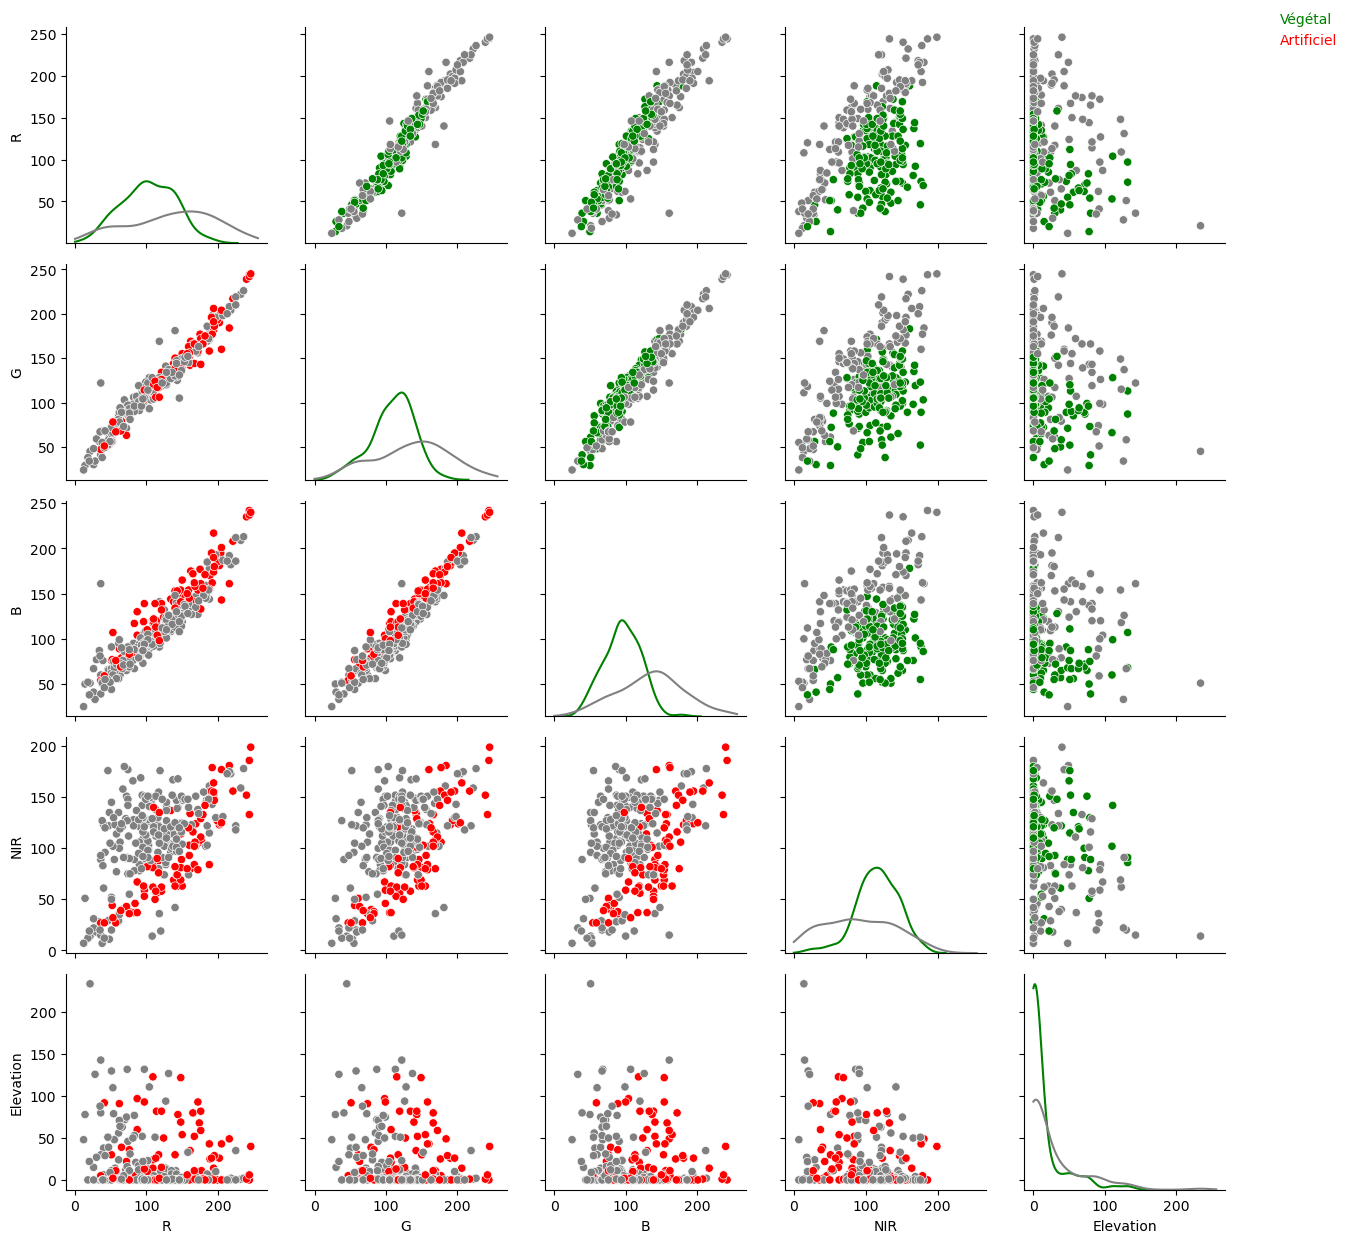

In [11]:
vars = ['R', 'G', 'B', 'NIR', 'Elevation']
vegetal_palette = sns.color_palette(["grey","green"])
artificial_palette = sns.color_palette(["grey","red"])
sub_df = train_pixel_df.sample(n=300, random_state=42)
g=sns.PairGrid(data=sub_df, vars=vars, hue='Vegetal', palette=vegetal_palette)

g.map_diag(sns.kdeplot, clip=[0,256])
#
g.map_upper(sns.scatterplot,hue = sub_df.Vegetal, palette=vegetal_palette)
#
g.map_lower(sns.scatterplot,hue = sub_df.Artificial, palette=artificial_palette) 
#
# add legend for upper plots hue
g.add_legend(label_order=['Végétal','Artificiel'], labelcolor=['green','red'], title='', loc='upper right')


 


In [12]:
# make many logist regression 
# to choose for a pedagogic progression
def make_logistic_regression(X_train, X_test, y_train, y_test):
    pipeline = Pipeline(steps=[('scaler', StandardScaler()),
                               ('log_reg', LogisticRegression())])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    # create a sklearn pipeline
    return pipeline, score


all_X_vars = ['R', 'G', 'B','NIR','Elevation']
all_y_vars = ['Artificial', 'Vegetal']

# enumerate all the possible combinations of 3 variables
estimators = dict()

for y_var in all_y_vars:
    estimators[y_var] = dict()
    for i in range (1, len(all_X_vars)+1):
        for X_vars in combinations(all_X_vars, i):
            #print(f"X_vars:{X_vars}")
            logreg, score = make_logistic_regression(X_train = train_pixel_df[list(X_vars)].values,
                                                     X_test  = test_pixel_df[list(X_vars)].values,
                                                     y_train = train_pixel_df[y_var].values,
                                                     y_test  = test_pixel_df[y_var].values)
            reg_equation = f"{y_var}~{'+'.join(X_vars)}"
            print(reg_equation+f"\t\t\t\t f score is {score}")
            estimators[reg_equation] = logreg
#print(dict(zip(vars,logreg.coef_[0 ])))
#print(f"f score is {score}")


Artificial~R				 f score is 0.7422
Artificial~G				 f score is 0.7509
Artificial~B				 f score is 0.7845
Artificial~NIR				 f score is 0.6863
Artificial~Elevation				 f score is 0.6862
Artificial~R+G				 f score is 0.7419
Artificial~R+B				 f score is 0.8077
Artificial~R+NIR				 f score is 0.7728
Artificial~R+Elevation				 f score is 0.7578
Artificial~G+B				 f score is 0.8414
Artificial~G+NIR				 f score is 0.7714
Artificial~G+Elevation				 f score is 0.7671
Artificial~B+NIR				 f score is 0.8073
Artificial~B+Elevation				 f score is 0.7972
Artificial~NIR+Elevation				 f score is 0.6836
Artificial~R+G+B				 f score is 0.8466
Artificial~R+G+NIR				 f score is 0.773
Artificial~R+G+Elevation				 f score is 0.7564
Artificial~R+B+NIR				 f score is 0.8146
Artificial~R+B+Elevation				 f score is 0.8129
Artificial~R+NIR+Elevation				 f score is 0.7854
Artificial~G+B+NIR				 f score is 0.8436
Artificial~G+B+Elevation				 f score is 0.8449
Artificial~G+NIR+Elevation				 f score is 0.7864
Artif

memo: in 'IMG_073414' prediction seems better than human mask

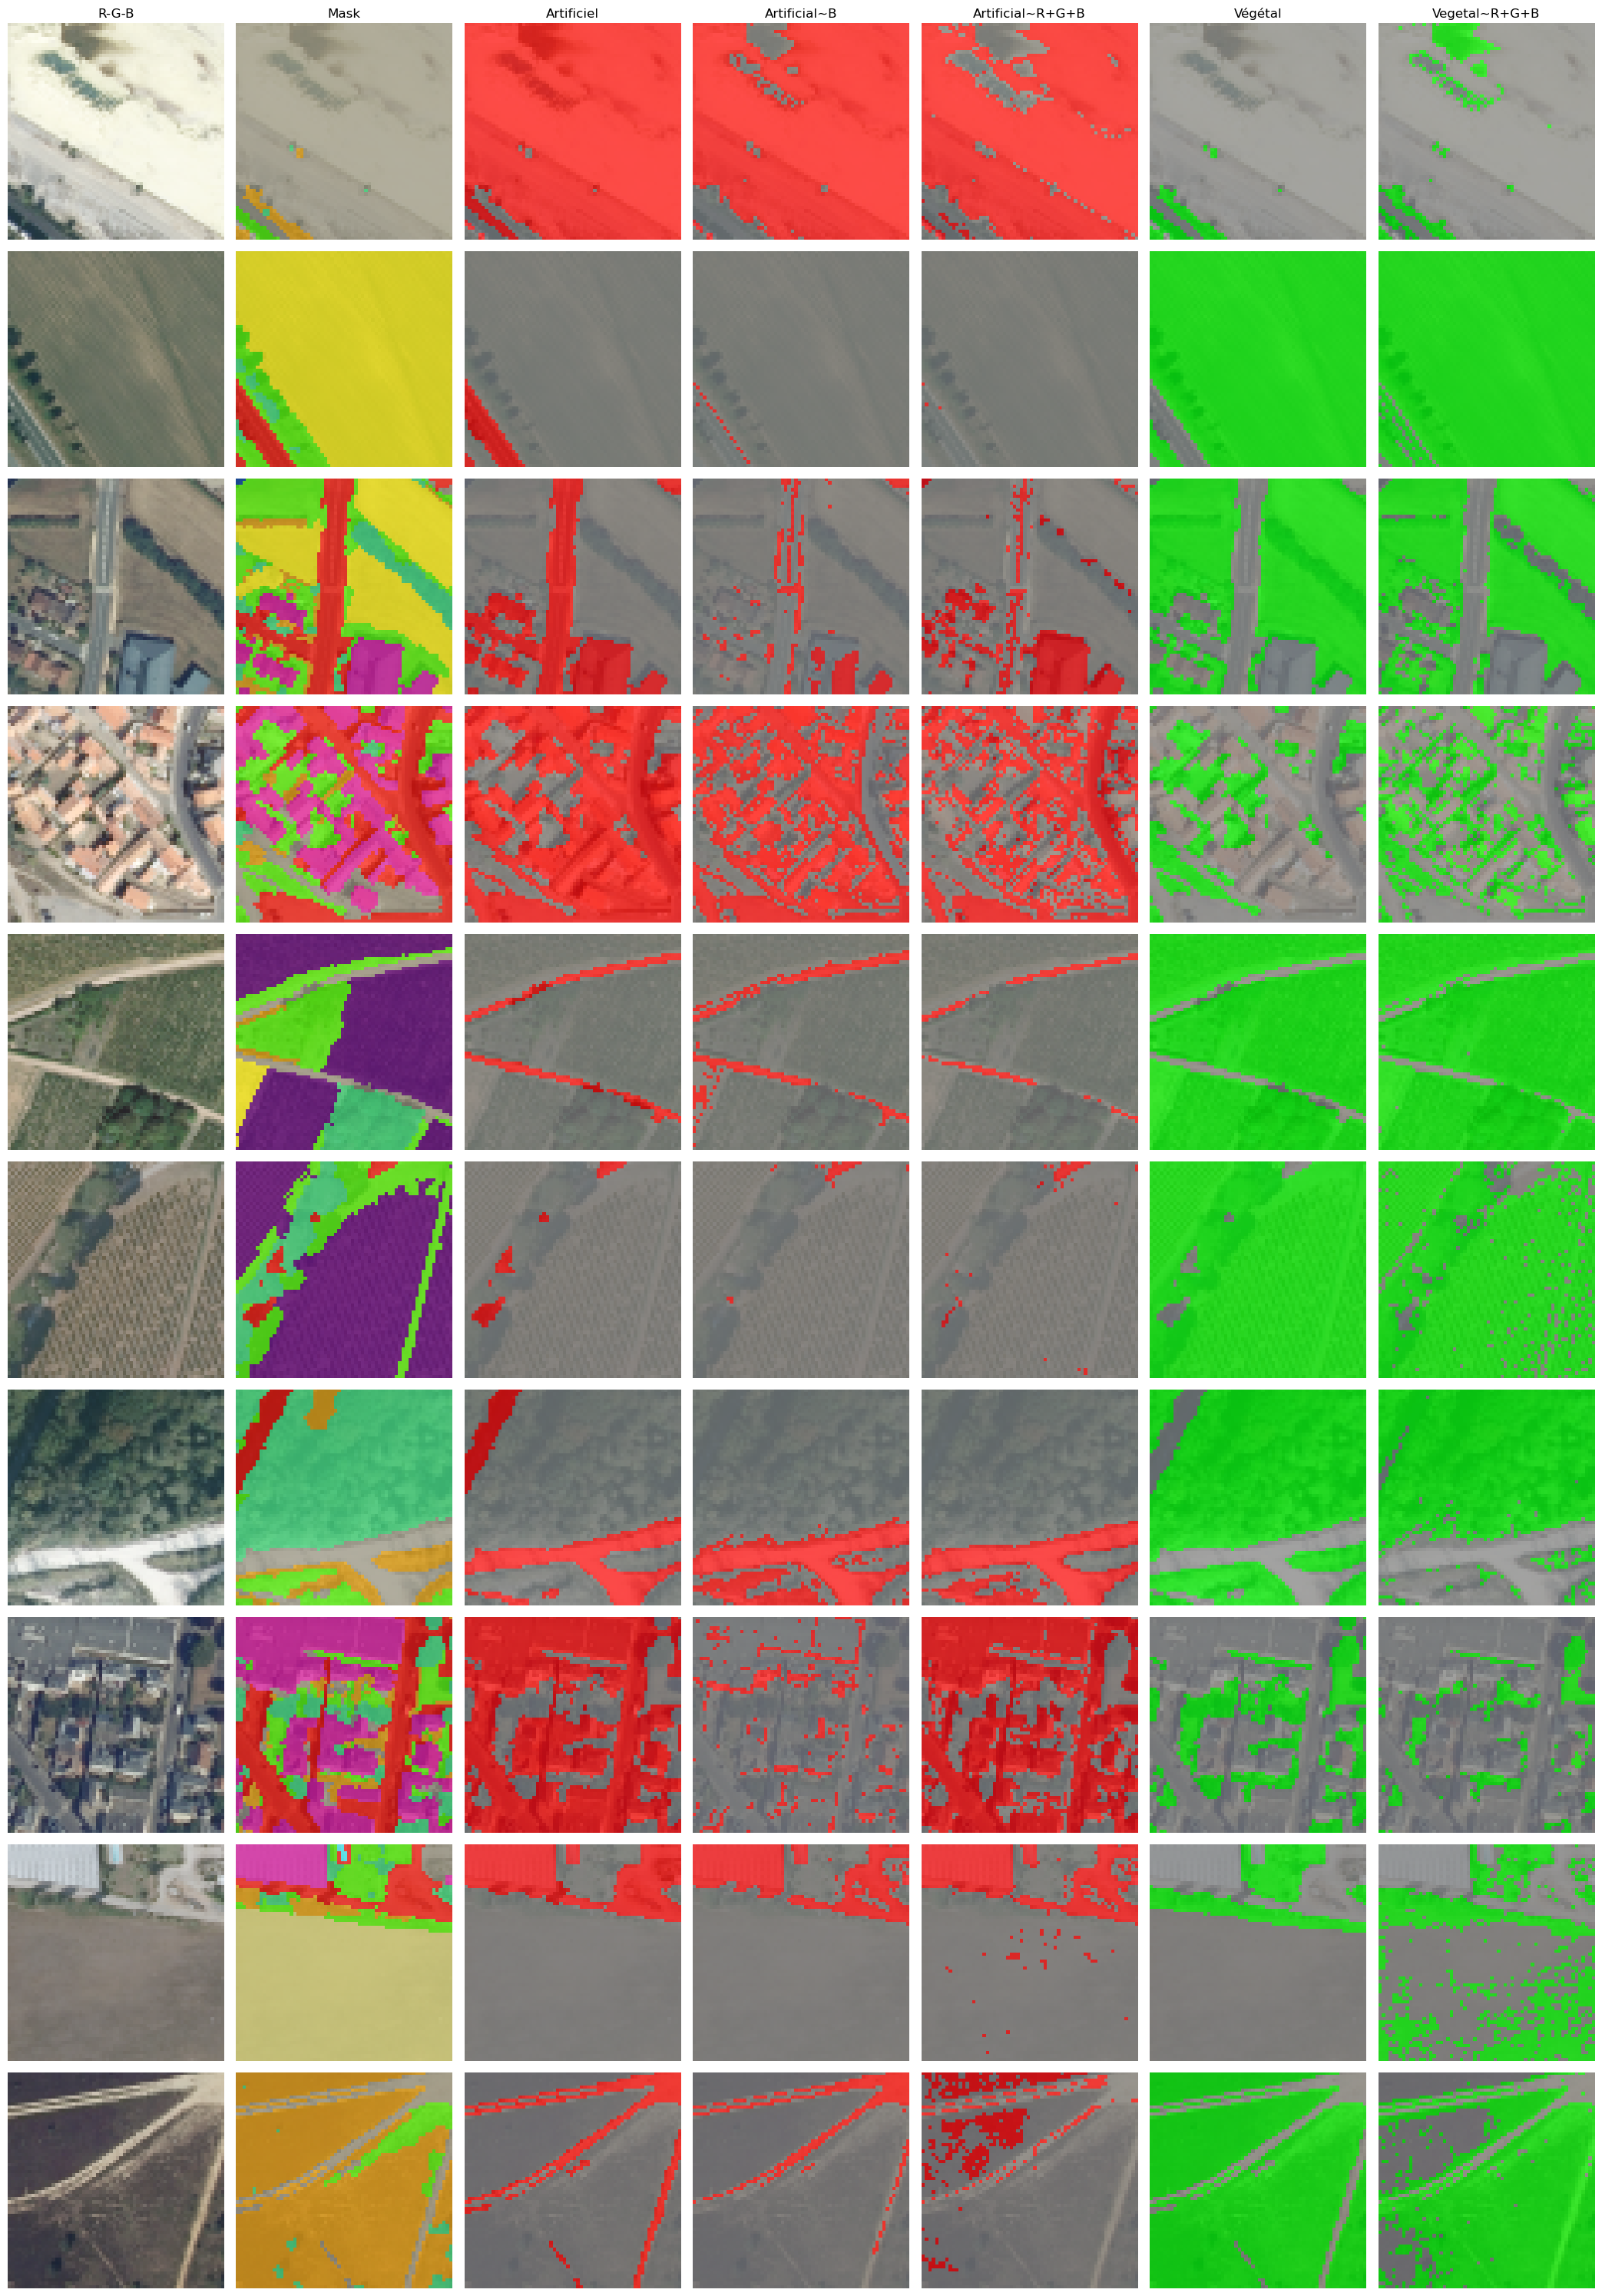

In [13]:
# set seed for df.sample() to get reproducible results
if False:
    seed = 10041958
    np.random.seed(seed)

# TODO: work from image_indices, not directly from df
# select a random record from df
# and extract the name, image and mask file paths.
# print(name)
# print(image_file)
# print(mask_file)
nl, nc = 10,7
im_alpha = 0.7
plt.figure(figsize=(nc*3, nl*3))
for i_l, i_test_record in enumerate(np.random.choice(a=test_image_data.shape[0], size=nl)):
    record = test_image_data[i_test_record]
    im = record[:,:,:3]
    msk = record[:,:,-3]
    msk_a = record[:,:,-2]
    msk_v = record[:,:,-1]

    #    
    plt.subplot(nl, nc, i_l*nc+1)
    plt.imshow(im)
    if i_l == 0: plt.title("R-G-B")
    plt.axis("off")
    #
    msk_palette = class_to_rgb(arr=msk, conf=conf)
    plt.subplot(nl, nc, i_l*nc+2)
    plt.imshow(im)
    plt.imshow(msk_palette, alpha=im_alpha)
    
    if i_l == 0: plt.title("Mask")
    plt.axis("off")
    #
    msk_artificiel = artificial_to_rgb(arr=msk_a,  conf=conf)
    plt.subplot(nl, nc, i_l*nc+3)
    plt.imshow(im)
    plt.imshow(msk_artificiel, alpha=im_alpha)
    
    
    
    if i_l == 0: plt.title("Artificiel")
    plt.axis("off")
    #
    reg_equation = 'Artificial~B'
    msk_pred = estimators[reg_equation].predict(im[:,:,2].reshape(-1,1)).reshape(im.shape[:2])
    rgb_pred = artificial_to_rgb(conf=conf, arr=msk_pred)
    plt.subplot(nl, nc, i_l*nc+4)
    plt.imshow(im)
    plt.imshow(rgb_pred, alpha=im_alpha)
    if i_l == 0: plt.title(reg_equation)
    plt.axis("off")
    #
    reg_equation = 'Artificial~R+G+B'
    msk_pred = estimators[reg_equation].predict(im.reshape(-1,3)).reshape(im.shape[:2])
    rgb_pred = artificial_to_rgb(conf=conf, arr=msk_pred)
    plt.subplot(nl, nc, i_l*nc+5)
    plt.imshow(im)
    plt.imshow(rgb_pred, alpha=im_alpha)
    if i_l == 0: plt.title(reg_equation)
    plt.axis("off")
    #
    #
    msk_vegetal = vegetal_to_rgb(arr=msk_v, conf=conf)
    plt.subplot(nl, nc, i_l*nc+6)
    plt.imshow(im)
    plt.imshow(msk_vegetal, alpha=im_alpha)
    if i_l == 0: plt.title("Végétal")
    plt.axis("off")
    #

    reg_equation = 'Vegetal~R+G+B'
    msk_pred = estimators[reg_equation].predict(im.reshape(-1,3)).reshape(im.shape[:2])
    rgb_pred = vegetal_to_rgb(conf=conf, arr=msk_pred)
    plt.subplot(nl, nc, i_l*nc+7)
    plt.imshow(im)
    plt.imshow(rgb_pred, alpha=im_alpha)
    if i_l == 0: plt.title(reg_equation)
    plt.axis("off")
    #
plt.tight_layout()
plt.show()
